# Predicting Student Health Risk — v2: LightGBM Baseline
### Kaggle Playground Series S6E7

**v1 recap:** RandomForest baseline scored **CV balanced accuracy = 0.86212**.

**What's different in v2:**
- Swapped `RandomForestClassifier` → `LGBMClassifier` (gradient boosting usually handles tabular feature interactions better)
- Native categorical feature support (no need to label-encode categories — LightGBM handles them directly, which often helps)
- Same 5-fold StratifiedKFold + balanced accuracy setup as v1, so the fold scores are directly comparable

Same pipeline shape as before: Load → EDA → Preprocess → Train/Validate → Predict → Submit.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/competitions/playground-series-s6e7"


## 1. Load the data

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (690088, 15)
Test shape: (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. Quick EDA checks

Same checks as v1 — worth re-confirming class balance here since it affects how we set `class_weight`.

In [3]:
target_col = "health_condition"
print(train[target_col].value_counts())
print()
print(train[target_col].value_counts(normalize=True))

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64


In [4]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None found")

Columns with missing values:
stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
dtype: int64


## 3. Preprocessing

Key difference from v1: LightGBM can handle categorical columns natively if we tell it which
columns are categorical (via pandas `category` dtype) — no need to LabelEncode them into
arbitrary integers, which can sometimes mislead tree splits.

In [5]:
feature_cols = [c for c in train.columns if c not in [target_col, "id"]]

X = train[feature_cols].copy()
y = train[target_col].copy()
X_test = test[feature_cols].copy()

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
Numeric columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


In [6]:
# Numeric missing values: median fill (same as v1)
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())
    X_test[c] = X_test[c].fillna(X[c].median())

# Categorical missing values: keep as its own "missing" category
for c in cat_cols:
    X[c] = X[c].fillna("missing").astype("category")
    X_test[c] = X_test[c].fillna("missing").astype("category")

# Make sure train/test share the same category levels
for c in cat_cols:
    all_cats = pd.concat([X[c], X_test[c]]).astype(str).unique()
    X[c] = X[c].astype(str).astype(pd.CategoricalDtype(categories=all_cats))
    X_test[c] = X_test[c].astype(str).astype(pd.CategoricalDtype(categories=all_cats))

# Encode the target labels (at-risk / unhealthy / fit -> 0/1/2)
target_encoder = LabelEncoder()
y_enc = target_encoder.fit_transform(y)
print(dict(zip(target_encoder.classes_, range(len(target_encoder.classes_)))))

{'at-risk': 0, 'fit': 1, 'unhealthy': 2}


## 4. Train and validate with LightGBM

Same StratifiedKFold(5) + balanced_accuracy setup as v1 — compare fold-by-fold scores directly
against your RF baseline.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
test_preds_folds = []
feature_importances = np.zeros(len(feature_cols))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_enc)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_enc[train_idx], y_enc[val_idx]

    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",   # same rationale as v1's RF
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[]
    )

    val_pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold+1} balanced accuracy: {score:.5f}")

    test_preds_folds.append(model.predict_proba(X_test))
    feature_importances += model.feature_importances_ / skf.n_splits

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print(f"v1 (RandomForest) was: 0.86212 for comparison")

Fold 1 balanced accuracy: 0.94957
Fold 2 balanced accuracy: 0.95114
Fold 3 balanced accuracy: 0.94898
Fold 4 balanced accuracy: 0.94864
Fold 5 balanced accuracy: 0.94700

Mean CV balanced accuracy: 0.94907 (+/- 0.00134)
v1 (RandomForest) was: 0.86212 for comparison


## 5. Feature importance — which features matter most?

bmi                        26520.6
sleep_duration             26051.8
exercise_duration          24419.4
step_count                 24104.8
calorie_expenditure        23661.0
heart_rate                 23032.0
water_intake               22663.4
stress_level                4281.2
smoking_alcohol             2613.4
diet_type                   2611.6
physical_activity_level     2419.6
sleep_quality               2344.6
gender                      1276.6
dtype: float64

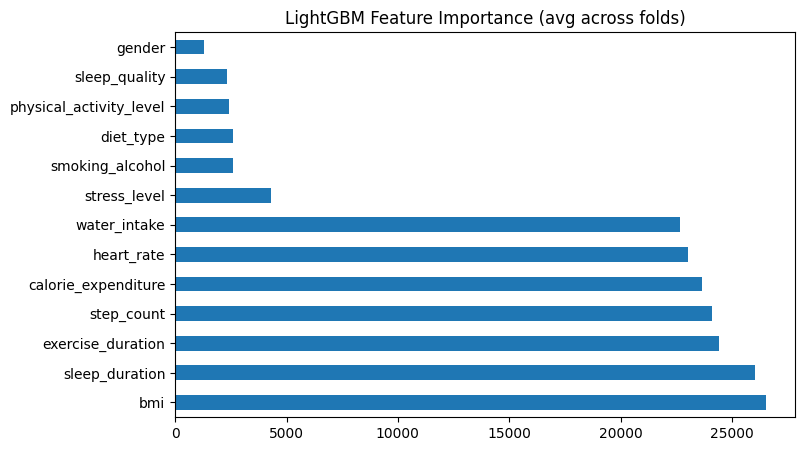

In [8]:
fi = pd.Series(feature_importances, index=feature_cols).sort_values(ascending=False)
fi.plot(kind="barh", figsize=(8,5), title="LightGBM Feature Importance (avg across folds)")
fi

## 6. Predict on the test set

In [9]:
avg_test_proba = np.mean(test_preds_folds, axis=0)
final_preds_enc = np.argmax(avg_test_proba, axis=1)
final_preds = target_encoder.inverse_transform(final_preds_enc)

print(pd.Series(final_preds).value_counts())

at-risk      240856
unhealthy     33342
fit           21555
Name: count, dtype: int64


## 7. Build and save the submission file

In [10]:
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": final_preds
})

assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
